In [1]:
5+5

10

In [1]:
import sys
import os 
from dotenv import load_dotenv
from pageindex import PageIndexClient
from langchain.chat_models import init_chat_model
from loguru import logger
import requests

from langchain.messages import SystemMessage, HumanMessage
from pydantic import BaseModel, Field
from typing import List, Dict , Any


load_dotenv()

# Add the parent directory (project root) to sys.path
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

# Now you can import from src
from src.retrieval_block.tree_retrieval import TreeRetrieval


In [ ]:
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
GROQ_API_KEY =  os.getenv("GROQ_API_KEY") 
Page_index_api = os.getenv("Page_index_api")


pi_client = PageIndexClient(api_key =Page_index_api )
from langchain.chat_models import init_chat_model
llm = init_chat_model("google_genai:gemini-2.0-flash" , api_key = GOOGLE_API_KEY)

llm = init_chat_model(
    "openai/gpt-oss-120b",  # Example Groq model name
    model_provider="groq",
    # You might also include other parameters like timeout, max_retries, etc.
    timeout=60.0,
    max_retries=0, # Disable retries for immediate timeout
    api_key = GROQ_API_KEY
)

In [3]:
llm.invoke("اهلا")

AIMessage(content='أهلاً وسهلاً! كيف يمكنني مساعدتك اليوم؟', additional_kwargs={'reasoning_content': 'The user says "اهلا" which is Arabic for "hello". We should respond in Arabic greeting. Follow guidelines: be helpful, friendly.'}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 73, 'total_tokens': 126, 'completion_time': 0.112219134, 'completion_tokens_details': {'reasoning_tokens': 30}, 'prompt_time': 0.014407736, 'prompt_tokens_details': None, 'queue_time': 0.028515708, 'total_time': 0.12662687}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_45da596066', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d9bf7-164a-7a32-b80e-0a05460e026c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 73, 'output_tokens': 53, 'total_tokens': 126, 'output_token_details': {'reasoning': 30}})

In [4]:
tree_retrieval = TreeRetrieval(pi_client)

# pushover

In [5]:
# For pushover

pushover_user = os.getenv("PUSHOVER_USER")
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_url = "https://api.pushover.net/1/messages.json"

if pushover_user:
    print(f"Pushover user found and starts with {pushover_user[0]}")
else:
    print("Pushover user not found")

if pushover_token:
    print(f"Pushover token found and starts with {pushover_token[0]}")
else:
    print("Pushover token not found")

Pushover user found and starts with u
Pushover token found and starts with a


In [6]:
def push(message):
    print(f"Push: {message}")
    payload = {"user": pushover_user, "token": pushover_token, "message": message}
    requests.post(pushover_url, data=payload)
    
push("HEY!!")


Push: HEY!!


# Graph state

In [7]:
from pydantic import BaseModel, Field
from typing import List, Dict, Any, Optional
from langchain.messages import AnyMessage
from typing_extensions import Annotated
import operator


class GraphState(BaseModel):
    # input
    messages: Annotated[List[AnyMessage], operator.add] = Field(default_factory=list)
    user_query: str = ""

    docs_titles: List[Dict] = Field(default_factory=list)

    # router outputs
    router_outputs: Dict[str, Any] = Field(default_factory=dict)

    # title node
    selected_docs_indexes: List[int] = Field(default_factory=list)

    # context selector
    target_docs: List[Dict] = Field(default_factory=list)

 

# prompts

In [ ]:
Router_SYSTEM_PROMPT = """
You are a smart routing + tool planning agent in a RAG system.

Your job is to:
 - Decide if retrieval is needed


Available documents:
{docs_titles_names}

===========================
Rules:

1. GENERAL questions (greetings, casual talk):
→ need_retrieval = False


2. DOCUMENT / EXPERIENCE questions:
→ need_retrieval = True

===========================
Output STRICTLY this JSON:
- need_retrieval

"""


In [51]:
len(Router_SYSTEM_PROMPT)

408

In [52]:
len(Router_SYSTEM_PROMPT.strip())

405

In [53]:
print(Router_SYSTEM_PROMPT.strip())

You are a smart routing + tool planning agent in a RAG system.

Your job is to:
 - Decide if retrieval is needed


Available documents:
{docs_titles_names}

Rules:

1. GENERAL questions (greetings, casual talk):
→ need_retrieval = False


2. DOCUMENT / EXPERIENCE questions:
→ need_retrieval = True







Output STRICTLY this JSON:
- need_retrieval


In [9]:
Docs_titles_SYSTEM_PROMPT = """
You are a document selector in a RAG system.

Your task:
Select the MOST relevant document indexes to answer the query.

Rules:
- Return ONLY relevant indexes
- If unsure, return empty list []
- Do NOT guess

Available documents:
{docs_titles}

Output:
selected_indexes: list[int]
"""

In [10]:
Docs_toc_SYSTEM_PROMPT = """
You are a fine-grained document selector.

Your task:
1) Choose relevant documents
2) Choose specific section IDs داخل كل document

Rules:
- Be precise (avoid selecting all sections)
- Only include relevant IDs
- If nothing matches → return empty list

Available TOC:
{docs_toc}

Output:
selected_docs: [
  {{doc_index: int, target_ids: list[str]}}
]
"""

In [11]:
Generator_SYSTEM_PROMPT = """
Act like a professional AI assistant simulating a real human AI Engineer persona.

Your goal is to accurately and naturally answer questions about Abdelrahman Mohamed (AI Engineer from Cairo, Egypt) using ONLY the provided context, while maintaining high reliability, strict grounding, and clear communication.

Task: Answer user questions about experience, projects, and skills in a concise, human, and natural Egyptian Arabic tone.

Requirements:
1) Strictly use ONLY the provided context. Do NOT infer, assume, or invent any information.
2) If the answer is not موجود في الكونتكست:
   - Politely say you don’t have that information, OR
   - Use the appropriate tool if required.
3) Keep answers short and clear (3–5 sentences maximum).
4) Maintain a natural, friendly, human tone (not robotic).
5) Never switch language — always respond in Egyptian Arabic.
6) Do NOT expand beyond the user’s question or add extra details.

Context:
///
{retrieved_docs}
///

Available Tools:
1) record_user_details  
   - Use ONLY when:
     • User asks to contact  
     • User shares email or phone  
     • User requests collaboration  

2) record_unknown_question  
   - Use ONLY when:
     • Question is خارج نطاق الخبرة (not about career)  
     • Answer is not موجود في الكونتكست  
     • You are not confident in the answer  

Constraints:
- Format: Short paragraph (no bullets unless necessary)
- Style: Natural, conversational, concise
- Scope: Only career-related (experience, projects, skills)
- Reasoning: Think step-by-step internally, but DO NOT show reasoning
- Tool usage: Use tools only when conditions are strictly met
- Hallucination: Zero tolerance — never fabricate information

Self-check before answering:
- Is the answer fully grounded in the context?
- Is it within 3–5 sentences?
- Is it in Egyptian Arabic and sounds human?
- Did I avoid adding any extra or assumed information?

Take a deep breath and work on this problem step-by-step.
"""


# Schemas

In [12]:

class RouteNodeSchema(BaseModel):
    need_retrieval: bool = Field(
        ...,
        description="True if external retrieval is required, otherwise False."
    )

    

In [13]:
class DocsTitleNodeSchema(BaseModel):
    selected_indexes: List = Field(
        default=[],
        description="The docs indexes related to the user query."
    )

In [14]:
# target_docs = [{"doc_index": 0, "target_ids": [ "0007"]} , {{"doc_index": 1, "target_ids": [ "0005" , "0007"]}}]


class TargetDoc(BaseModel):
    doc_index: int = Field(
        ...,
        description="Index of the document in the docs list"
    )
    target_ids: List[str] = Field(
        ...,
        description="List of relevant chunk or section IDs داخل الدوك"
    )

class DocsTocNodeSchema(BaseModel):
    selected_docs: List[TargetDoc] = Field(
        default_factory=list,
        description="List of documents and their relevant target IDs for the query"
    )

# Tools

In [15]:

from langchain.tools import tool

@tool
def record_user_details(
    email: str= "", 
    phone_number: str = "",
    name: str = "Unknown",
    notes: str = ""
):
    """
    Record user contact details for follow-up or future communication.

    Use this tool when:
    - The user wants to contact Abdelrahman
    - The user shares their email or phone number
    - The user expresses interest in communication or collaboration

    Args:
        email (str): User's email address.
        phone_number (str): User's phone number.
        name (str, optional): User's name. Defaults to "Unknown".
        notes (str, optional): Additional notes or context provided by the user.

    Returns:
        dict: Confirmation that the user details were recorded.
    """
    push(f"[CONTACT] {name} | Email: {email} | Phone: {phone_number} | Notes: {notes}")
    return {"status": "recorded"}

@tool
def record_unknown_question(
    question: str,
    name: str = "Unknown"
):
    """
    Log a user question that the system could not answer.

    Use this tool when:
    - The system does not have enough information to answer
    - The answer requires human intervention

    Args:
        question (str): The user's question that could not be answered.
        name (str, optional): Name of the user (if available). Defaults to "Unknown".

    Returns:
        dict: Confirmation that the question was recorded.
    """
    push(f"[UNKNOWN QUESTION] {name}: {question}")
    return {"status": "recorded"}



tools = [record_user_details, record_unknown_question]

tools_by_name = {tool.name: tool for tool in tools}






# route node

In [16]:

route_node_llm = llm.with_structured_output(RouteNodeSchema)


# query = "عاوز اتواصل معاك وده رقمي 53435132 واسمي احمد فضل"
# docs_titles_names = {"name": "hello"}
# response = route_node_llm.invoke([
#     SystemMessage(content=Router_SYSTEM_PROMPT.format(docs_titles_names = docs_titles_names)),
#     HumanMessage(content=query)
# ])

# print(response)


In [17]:
# docs_titles_names = {"name": "hello"}

# Router_SYSTEM_PROMPT.format(
#     docs_titles_names=docs_titles_names
# )



In [18]:
from langchain.messages import AIMessage

def router_node(state: GraphState):

    docs_titles_names = [doc["name"] for doc in state.docs_titles]
    user_query = HumanMessage(content=state.user_query) 
    response = route_node_llm.invoke([
        SystemMessage(content=Router_SYSTEM_PROMPT.format(docs_titles_names=docs_titles_names)),
        user_query
    ])

    json_res = response.model_dump()

    return {
        "router_outputs": json_res
    }

# Docs titles node

In [19]:
docs_titles = tree_retrieval.get_docs_titles()

docs_titles # -- > list of indexes [ 0 , 1 ....]

[{'doc_index': 0,
  'name': 'projects_portfolio_in_github.pdf',
  'description': 'This document outlines a data science portfolio showcasing projects in data analysis, visualization, machine learning, recommendation systems, time series forecasting, deep learning, and natural language processing.'},
 {'doc_index': 1,
  'name': 'my_Linkedin.pdf',
  'description': 'This document outlines the experience of Abdelrahman Mohamed, an AI Engineer specializing in LLM agents, RAG pipelines, and real-time AI assistants, with roles at Electro Pi, Sand Technologies, and ALX Arabia.'},
 {'doc_index': 2,
  'name': 'Abdelrahman_Mohamed_CV_14.9_1.pdf',
  'description': 'This document is a resume for Abdelrahman Mohamed, an AI/ML Engineer with experience in GenAI systems, LLM fine-tuning, RAG pipelines, and real-time voice assistants, with a focus on Arabic AI applications.'}]

In [20]:


docs_titles_node_llm = llm.with_structured_output(DocsTitleNodeSchema)





query = "ايه هي المشاريع الي اشتغلت عليها؟"

response = docs_titles_node_llm.invoke([
    SystemMessage(content=Docs_titles_SYSTEM_PROMPT.format(docs_titles = docs_titles)),
    HumanMessage(content=query)
])

print(response)


selected_indexes=[0]


In [21]:
def Docs_titles_node(state: GraphState):
    user_query = HumanMessage(content=state.user_query) 
    
    # Use state.docs_titles instead of global docs_titles
    response = docs_titles_node_llm.invoke([
        SystemMessage(content=Docs_titles_SYSTEM_PROMPT.format(docs_titles = state.docs_titles)),
        user_query
    ])

    json_res = response.model_dump()

    print("Docs_titles_node Output" , json_res)


    # Return the specific list of indexes, not the whole dictionary
    return {
        "selected_docs_indexes": json_res.get("selected_indexes", [])
    }


# docs TOC node

In [22]:
doc_indices = [0 , 2]
docs_toc = tree_retrieval.get_toc(doc_indices)

In [23]:
# docs_toc

In [24]:


docs_toc_node_llm = llm.with_structured_output(DocsTocNodeSchema)





query = "ايه هي خبرتك ؟"

response = docs_toc_node_llm.invoke([
    SystemMessage(content=Docs_toc_SYSTEM_PROMPT.format(docs_toc = docs_toc)),
    HumanMessage(content=query)
])

print(response)




selected_docs=[TargetDoc(doc_index=2, target_ids=['0002', '0003'])]


In [25]:
res = response.model_dump()

In [26]:
res['selected_docs']

[{'doc_index': 2, 'target_ids': ['0002', '0003']}]

In [27]:
def Docs_toc_node(state: GraphState):

    user_query = HumanMessage(content=state.user_query) 

    docs_toc = tree_retrieval.get_toc(state.selected_docs_indexes)

    response = docs_toc_node_llm.invoke([
    SystemMessage(content=Docs_toc_SYSTEM_PROMPT.format(docs_toc = docs_toc)),
    user_query
        ])

    print("Docs_toc_node Output" , response)

    json_res = response.model_dump()
    res_list = json_res['selected_docs']

    return {
        "target_docs": res_list
    }

# Generator node

In [28]:
target_docs = [{'doc_index': 2,
  'target_ids': ['0002',
   '0003',
   '0007',
   '0008',
   '0009',
   '0010',
   '0011',
   '0012']}, 
   {'doc_index': 0,
  'target_ids': ['0002',
   '0003']}]

retrieved_docs =  tree_retrieval.retrieve(target_docs)

# retrieved_docs

In [29]:

generator_node_llm = llm.bind_tools(tools)





query = "انت بتحب البطيخ؟"

response = generator_node_llm.invoke([
    SystemMessage(content=Generator_SYSTEM_PROMPT.format(retrieved_docs = retrieved_docs)),
    HumanMessage(content=query)
])

print(response)





content='معنديش معلومة عن تفضيلاتي الشخصية في الموضوع ده.' additional_kwargs={'reasoning_content': 'User asks "Do you like watermelon?" This is not about career. According to instructions, we must respond politely that we don\'t have that information, or use appropriate tool if required. This is a personal preference question, not in context. So we should say we don\'t have that info. Use tool record_unknown_question? The condition: answer is not موجود في الكونتكست. So we should either politely say we don’t have that info, OR use appropriate tool if required. We can just say we don’t have that info. No need to log unknown question? The tool is for logging when answer not available. Could use it. But not required. Probably just respond politely.'} response_metadata={'token_usage': {'completion_tokens': 161, 'prompt_tokens': 2453, 'total_tokens': 2614, 'completion_time': 0.349261729, 'completion_tokens_details': {'reasoning_tokens': 137}, 'prompt_time': 0.127173148, 'prompt_tokens_detail

In [30]:
response.tool_calls

[]

In [31]:
print(response.content)

معنديش معلومة عن تفضيلاتي الشخصية في الموضوع ده.


In [32]:
def generator_node(state: GraphState):

    retrieved_content =  tree_retrieval.retrieve(state.target_docs )
    user_query = HumanMessage(content=state.user_query) 
    response = generator_node_llm.invoke([
    SystemMessage(content=Generator_SYSTEM_PROMPT.format(retrieved_docs = retrieved_content)),
    user_query
    ] + state.messages)

    print(response)

    res = response.content
 

    return {
        "messages": [user_query , AIMessage(content=res)]
    }

# tools node

In [33]:
from langchain.messages import ToolMessage


def generator_tool_node(state: dict):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}

# Build and compile the agent 

In [34]:
from typing import Literal
from langgraph.graph import StateGraph, START, END

# Build workflow
agent_builder = StateGraph(GraphState)

In [35]:
from typing import Literal
from langgraph.graph import StateGraph, START, END


def should_continue(state: GraphState) -> Literal["generator_tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state.messages
    last_message = messages[-1]

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "generator_tool_node"

    # Otherwise, we stop (reply to the user)
    return END

In [36]:
def need_retrieve(state: GraphState):
    
    if state.router_outputs['need_retrieval']:
        return "Docs_titles_node"
    
    return "generator_node"

In [37]:
# Add nodes
agent_builder.add_node("router_node", router_node)
agent_builder.add_node("Docs_titles_node", Docs_titles_node)
agent_builder.add_node("Docs_toc_node", Docs_toc_node)
agent_builder.add_node("generator_node", generator_node)

agent_builder.add_node("generator_tool_node", generator_tool_node)

In [38]:
# Add edges to connect nodes
agent_builder.add_edge(START, "router_node")


agent_builder.add_conditional_edges(
    "router_node",
    need_retrieve,
    ["Docs_titles_node", "generator_node"]
)
agent_builder.add_edge("Docs_titles_node", "Docs_toc_node")
agent_builder.add_edge("Docs_toc_node", "generator_node")



agent_builder.add_conditional_edges(
    "generator_node",
    should_continue,
    ["generator_tool_node", END]
)


agent_builder.add_edge("generator_tool_node", "generator_node")

agent_builder.add_edge("generator_node", END)







In [39]:
# Compile the agent
agent = agent_builder.compile()

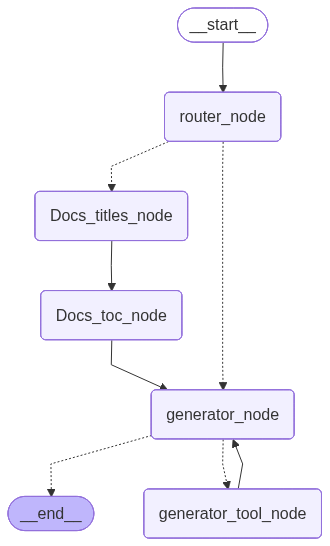

In [40]:
# Show the agent
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))


In [41]:
# Invoke
from langchain.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

docs_titles = tree_retrieval.get_docs_titles()



checkpointer = InMemorySaver()
agent = agent_builder.compile(checkpointer = checkpointer)

config = {"configurable": {"thread_id": "1"}}



In [42]:
query = "ايه اول سوال سالتهولك؟"


messages = agent.invoke({"user_query": query , "docs_titles": docs_titles} , config)
for m in messages["messages"]:
    m.pretty_print()

content='معنديش معلومات عن أول سؤال سألتهولي.' additional_kwargs={'reasoning_content': 'The user asks in Arabic: "ايه اول سوال سالتهولك؟" Means "What was the first question you asked me?" We need to answer based on context. The context is empty ( [] ), no prior conversation. The user is asking about the first question they asked me. We have no record of that. So we must say we don\'t have that information. According to rules, if answer not موجود في الكونتكست, politely say you don’t have that information. So answer in Egyptian Arabic, short 3-5 sentences, but can be 1-2 sentences. So: "معنديش معلومات عن السؤال الأول اللي سألتني بيه." That is sufficient.'} response_metadata={'token_usage': {'completion_tokens': 163, 'prompt_tokens': 814, 'total_tokens': 977, 'completion_time': 0.346731483, 'completion_tokens_details': {'reasoning_tokens': 142}, 'prompt_time': 0.224217973, 'prompt_tokens_details': None, 'queue_time': 0.235910665, 'total_time': 0.570949456}, 'model_name': 'openai/gpt-oss-1

In [43]:
messages

{'messages': [HumanMessage(content='ايه اول سوال سالتهولك؟', additional_kwargs={}, response_metadata={}),
  AIMessage(content='معنديش معلومات عن أول سؤال سألتهولي.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])],
 'user_query': 'ايه اول سوال سالتهولك؟',
 'docs_titles': [{'doc_index': 0,
   'name': 'projects_portfolio_in_github.pdf',
   'description': 'This document outlines a data science portfolio showcasing projects in data analysis, visualization, machine learning, recommendation systems, time series forecasting, deep learning, and natural language processing.'},
  {'doc_index': 1,
   'name': 'my_Linkedin.pdf',
   'description': 'This document outlines the experience of Abdelrahman Mohamed, an AI Engineer specializing in LLM agents, RAG pipelines, and real-time AI assistants, with roles at Electro Pi, Sand Technologies, and ALX Arabia.'},
  {'doc_index': 2,
   'name': 'Abdelrahman_Mohamed_CV_14.9_1.pdf',
   'description': 'This document is a resu